<a href="https://colab.research.google.com/github/rentenal/Code-Repo/blob/master/Conhe%C3%A7a_o_Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.model_selection import train_test_split
from google.colab import drive

# 1. Montar o Google Drive no ambiente do Colab
drive.mount('/content/drive')

# 2. Definir o caminho correto dentro do ambiente Linux do Colab
# No Colab, o "Meu Drive" é acessado por '/content/drive/MyDrive/'
file_path = '/content/drive/MyDrive/MBA_USP/dataset/WVS_Cross-National_Wave_7_csv_v6_0.csv'

# Colunas estratégicas para o seu TCC (Felicidade, Idade, Estoicismo, Lazer)
cols_to_use = [
    'Q262', # Idade Exata
    'Q49',  # Satisfação com a vida (Target)
    'Q48',  # Controle sobre a vida (Proxy de Estoicismo/Resiliência)
    'Q10',  # Importância do Lazer
    'Q273', # Estado Civil
    'Q281', # Renda
    'Q260'  # Gênero
]

try:
    # 3. Carregar o DataFrame
    df = pd.read_csv(file_path, usecols=cols_to_use)

    # 4. Limpeza de dados (Padrão WVS: valores negativos = não respondeu)
    df[df < 0] = np.nan
    df = df.dropna()

    # 5. Feature Engineering para a Curva em U
    df['Idade_Quadrada'] = df['Q262'] ** 2
    df['Lazer_x_Idade'] = df['Q10'] * df['Q262']

    print(f"Sucesso! Base carregada com {len(df)} linhas.")

    # 6. Preparação para o Machine Learning (XGBoost)
    X = df.drop('Q49', axis=1)
    y = df['Q49']

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    model = xgb.XGBRegressor(objective='reg:squarederror', n_estimators=100, learning_rate=0.1)
    model.fit(X_train, y_train)

    print("Modelo XGBoost treinado com os dados do seu Drive!")

except FileNotFoundError:
    print("Erro: Arquivo não encontrado. Verifique se o caminho no seu Google Drive está correto.")
    print(f"Tentado: {file_path}")
except Exception as e:
    print(f"Ocorreu um erro: {e}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Sucesso! Base carregada com 88582 linhas.
Modelo XGBoost treinado com os dados do seu Drive!


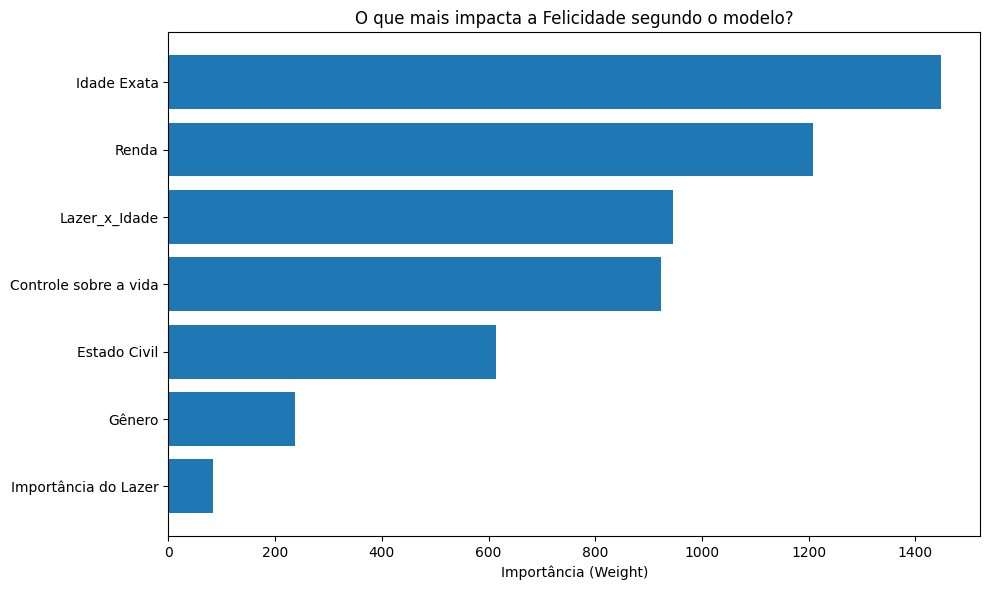

In [9]:
import matplotlib.pyplot as plt
import pandas as pd
import xgboost as xgb

# Mapeamento dos nomes
nomes_variaveis = {
    'Q262': 'Idade Exata',
    'Q49': 'Satisfação com a vida (Target)',
    'Q48': 'Controle sobre a vida',
    'Q10': 'Importância do Lazer',
    'Q273': 'Estado Civil',
    'Q281': 'Renda',
    'Q260': 'Gênero'
}

# Extrair a importância do modelo treinado
importancia = model.get_booster().get_score(importance_type='weight')

# Converter para DataFrame e ordenar
df_importancia = pd.DataFrame({
    'variavel': list(importancia.keys()),
    'importancia': list(importancia.values())
}).sort_values('importancia', ascending=False).head(10)  # Top 10

# Mapear os nomes (se alguma variável não estiver no dicionário, mantém o original)
df_importancia['variavel_legivel'] = df_importancia['variavel'].map(nomes_variaveis).fillna(df_importancia['variavel'])

# Plotar manualmente
plt.figure(figsize=(10, 6))
plt.barh(df_importancia['variavel_legivel'], df_importancia['importancia'])
plt.xlabel('Importância (Weight)')
plt.title("O que mais impacta a Felicidade segundo o modelo?")
plt.gca().invert_yaxis()  # Para que o maior fique em cima
plt.tight_layout()
plt.show()

In [6]:
from sklearn.metrics import mean_absolute_error, r2_score

y_pred = model.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Erro Médio Absoluto (MAE): {mae:.2f}")
print(f"R² (Poder de explicação): {r2:.2f}")

Erro Médio Absoluto (MAE): 1.50
R² (Poder de explicação): 0.21


<Figure size 1000x600 with 0 Axes>

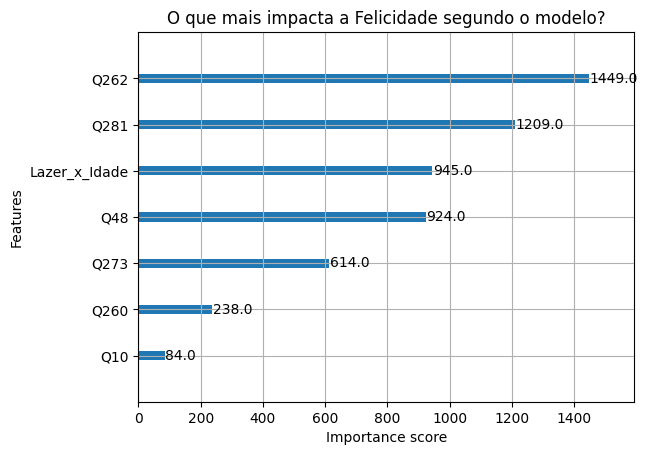

In [8]:
import matplotlib.pyplot as plt

# Pegando a importância das variáveis
plt.figure(figsize=(10, 6))
xgb.plot_importance(model, importance_type='weight', max_num_features=10)
plt.title("O que mais impacta a Felicidade segundo o modelo?")
plt.show()